In [2]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import pandas as pd

username = 'root'
password = 'Amritpal@123'      
host = 'localhost'
database = 'churn'      
pw_enc = quote_plus(password)

engine = create_engine(f"mysql+pymysql://{username}:{pw_enc}@{host}/{database}")
df = pd.read_sql("SELECT * FROM prod_churn", engine)
df.head()


,customer_id,gender,age,married,state,number_of_referrals,tenure_in_months,value_deal,phone_service,multiple_lines,...,payment_method,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,customer_status,churn_category,churn_reason
0,19877-DEL,Male,35,No,Delhi,7,27,none,Yes,No,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,others,others
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,none,Yes,Yes,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,others,others
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,none,Yes,No,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [5]:
df.isna().sum()

customer_id                    0
gender                         0
age                            0
married                        0
state                          0
number_of_referrals            0
tenure_in_months               0
value_deal                     0
phone_service                  0
multiple_lines                 0
internet_service               0
internet_type                  0
online_security                0
online_backup                  0
device_protection_plan         0
premium_support                0
streaming_tv                   0
streaming_movies               0
streaming_music                0
unlimited_data                 0
contract                       0
paperless_billing              0
payment_method                 0
monthly_charge                 0
total_charges                  0
total_refunds                  0
total_extra_data_charges       0
total_long_distance_charges    0
total_revenue                  0
customer_status                0
churn_cate

In [12]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
6413    False
6414    False
6415    False
6416    False
6417    False
Length: 6418, dtype: bool

In [6]:
df.describe()

,age,number_of_referrals,tenure_in_months,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue
count,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000,6418.000000
mean,47.070739,7.427859,17.342786,63.652867,2280.374858,1.924944,6.718604,748.703468,3033.871987
std,16.703633,4.621519,10.576391,31.188823,2268.049985,7.849083,24.722533,847.672844,2866.505426
min,18.000000,0.000000,1.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,33.000000,3.000000,8.000000,30.562500,395.725000,0.000000,0.000000,70.805000,603.742500
50%,46.000000,7.000000,16.000000,70.100000,1396.125000,0.000000,0.000000,407.475000,2108.635000
75%,60.000000,11.000000,27.000000,89.750000,3783.600000,0.000000,0.000000,1182.917500,4801.537500
max,85.000000,15.000000,36.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


In [7]:
num_col_data = df.select_dtypes(include=["number"])
num_col_data

,age,number_of_referrals,tenure_in_months,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue
0,35,7,27,65.60,593.30,0.00,0,381.51,974.81
1,45,14,13,-4.00,542.40,38.33,10,96.21,610.28
2,51,4,35,73.90,280.85,0.00,0,134.60,415.45
3,79,3,21,98.00,1237.85,0.00,0,361.66,1599.51
4,80,3,8,83.90,267.40,0.00,0,22.14,289.54
...,...,...,...,...,...,...,...,...,...
6413,41,6,33,74.40,896.75,0.00,0,37.96,934.71
6414,51,0,19,45.25,3139.80,0.00,0,0.00,3139.80
6415,65,14,25,74.95,2869.85,0.00,0,599.64,3469.49
6416,23,2,10,70.15,4480.70,0.00,0,2107.52,6588.22


In [8]:
num_col_data.corr()

,age,number_of_referrals,tenure_in_months,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue
age,1.000000,-0.009325,0.150851,0.134226,0.058049,0.017724,0.029559,0.005049,0.047629
number_of_referrals,-0.009325,1.000000,-0.010544,-0.006456,-0.000224,0.014115,-0.003736,0.011571,0.003174
tenure_in_months,0.150851,-0.010544,1.000000,-0.005104,-0.000433,0.010795,0.025323,0.004512,0.001181
monthly_charge,0.134226,-0.006456,-0.005104,1.000000,0.623008,0.022994,0.124129,0.232586,0.562727
total_charges,0.058049,-0.000224,-0.000433,0.623008,1.000000,0.036538,0.126160,0.608206,0.972069
total_refunds,0.017724,0.014115,0.010795,0.022994,0.036538,1.000000,0.021302,0.028200,0.034695
total_extra_data_charges,0.029559,-0.003736,0.025323,0.124129,0.126160,0.021302,1.000000,0.059328,0.125931
total_long_distance_charges,0.005049,0.011571,0.004512,0.232586,0.608206,0.028200,0.059328,1.000000,0.777379
total_revenue,0.047629,0.003174,0.001181,0.562727,0.972069,0.034695,0.125931,0.777379,1.000000


In [9]:
df["customer_status"].value_counts()

customer_status
Stayed     4275
Churned    1732
Joined      411
Name: count, dtype: int64

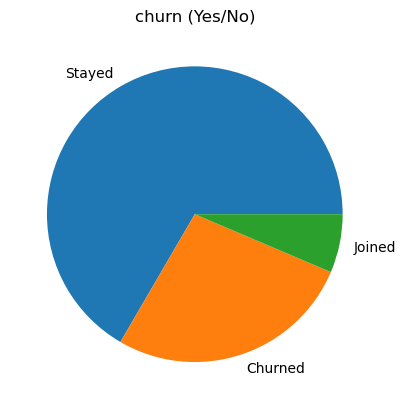

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
df["customer_status"].value_counts().plot(kind="pie")
plt.title("churn (Yes/No)")
plt.ylabel("")
plt.show()

In [13]:
df.groupby("customer_status")["monthly_charge"].mean()


customer_status
Churned    73.102252
Joined     42.683455
Stayed     61.840491
Name: monthly_charge, dtype: float64

In [15]:
df.groupby(["customer_status","gender"])["monthly_charge"].mean()

customer_status  gender
Churned          Female    74.565437
                 Male      70.484541
Joined           Female    42.289033
                 Male      43.430634
Stayed           Female    61.687388
                 Male      62.094680
Name: monthly_charge, dtype: float64

In [17]:
df.groupby("customer_status")["tenure_in_months"].mean()

customer_status
Churned    17.515589
Joined     16.586375
Stayed     17.345497
Name: tenure_in_months, dtype: float64

In [18]:
df.groupby("customer_status")["age"].mean()

customer_status
Churned    50.144919
Joined     43.878345
Stayed     46.132164
Name: age, dtype: float64

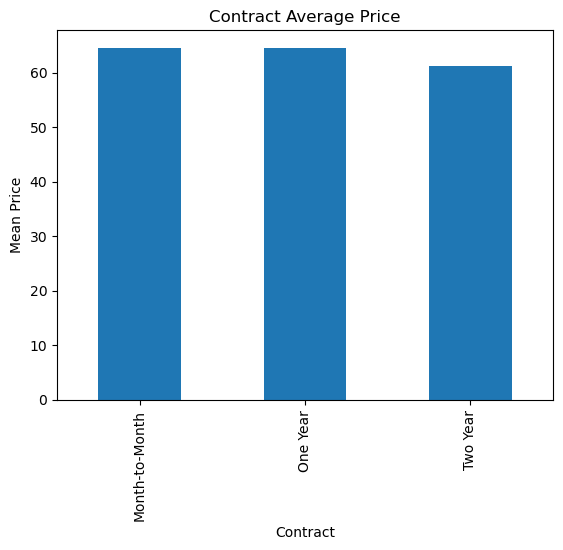

In [27]:
df.groupby("contract")["monthly_charge"].mean().plot(kind="bar")
plt.ylabel("Mean Price")
plt.xlabel("Contract")
plt.title("Contract Average Price")
plt.show()

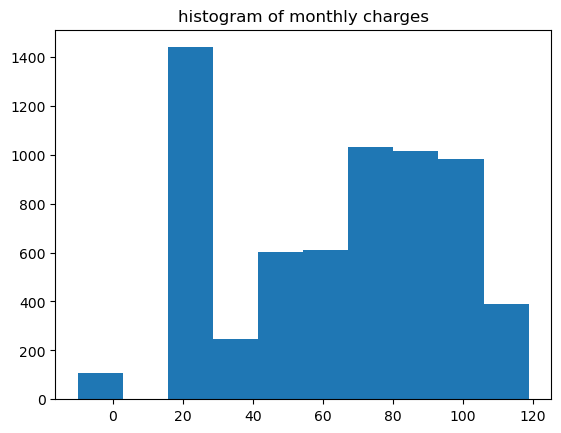

In [30]:
plt.hist(df["monthly_charge"])
plt.title("histogram of monthly charges")
plt.show()

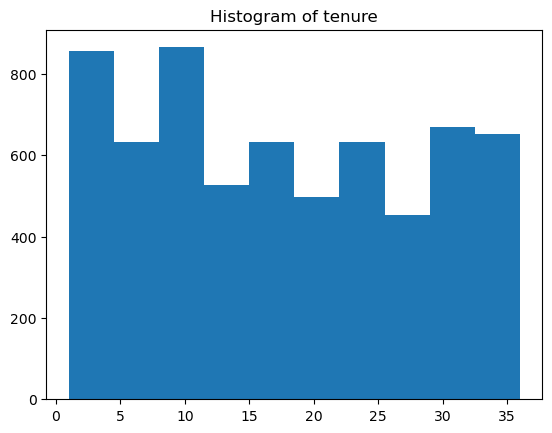

In [31]:
plt.hist(df["tenure_in_months"])
plt.title("Histogram of tenure")
plt.show()

In [35]:
df["gender"].apply(lambda x: 1 if x == "Female" else 0)

0       0
1       1
2       0
3       0
4       1
       ..
6413    1
6414    0
6415    1
6416    0
6417    0
Name: gender, Length: 6418, dtype: int64

In [34]:
df["gender"]

0         Male
1       Female
2         Male
3         Male
4       Female
         ...  
6413    Female
6414      Male
6415    Female
6416      Male
6417      Male
Name: gender, Length: 6418, dtype: object

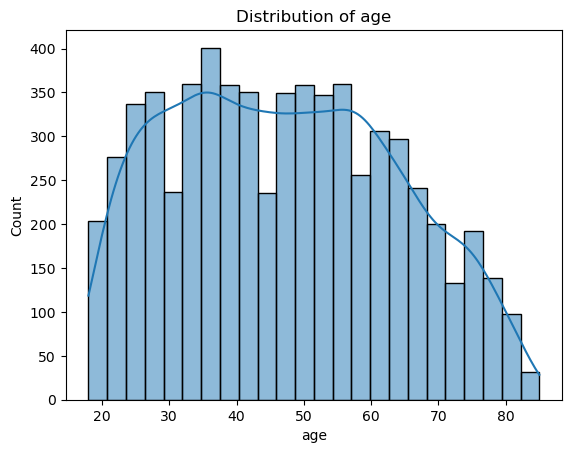

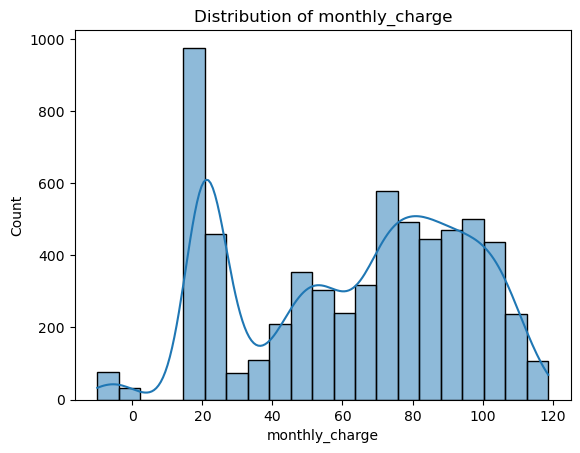

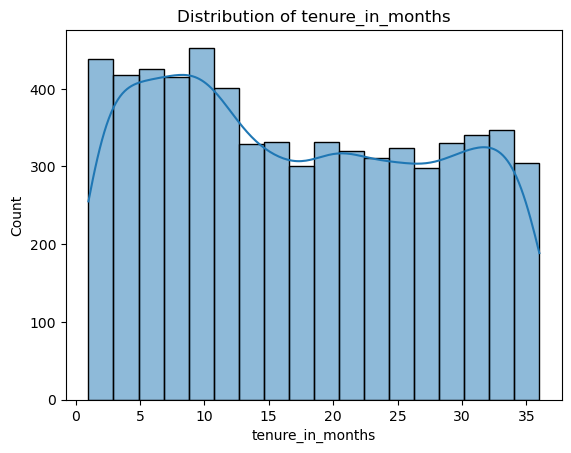

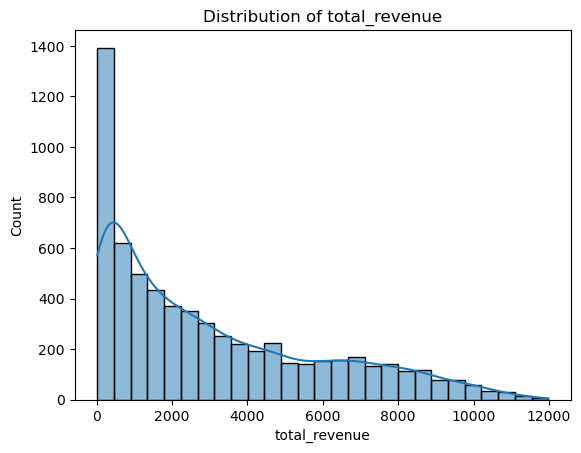

In [36]:
for col in ['age','monthly_charge','tenure_in_months','total_revenue']:
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

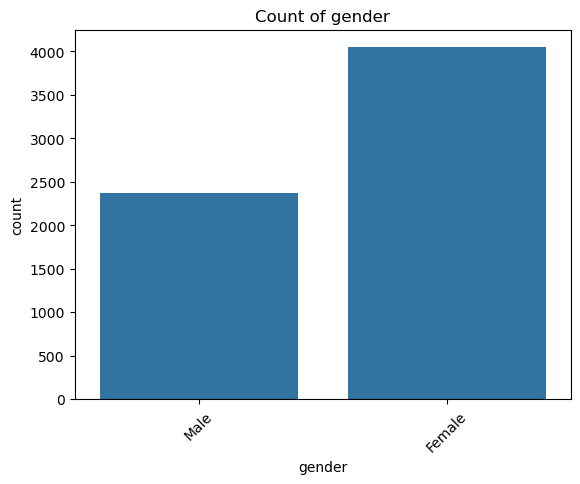

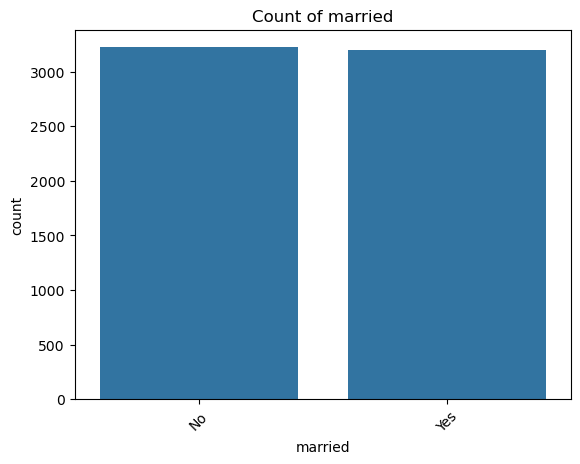

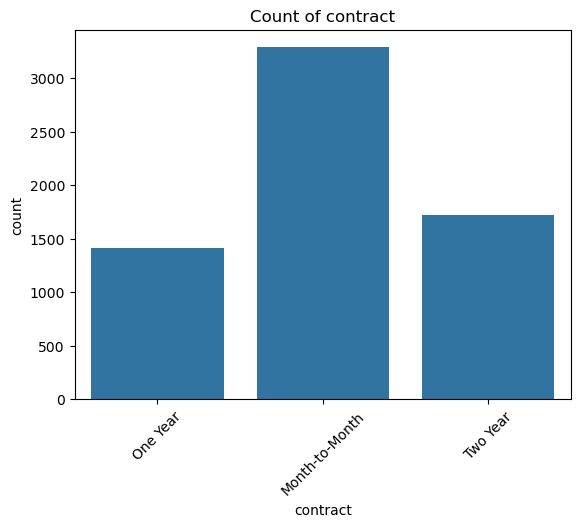

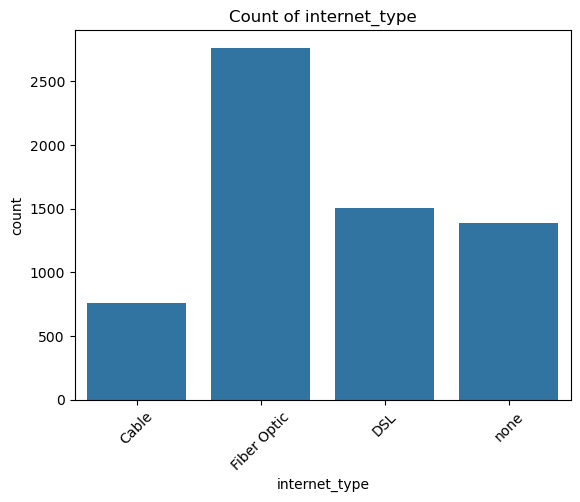

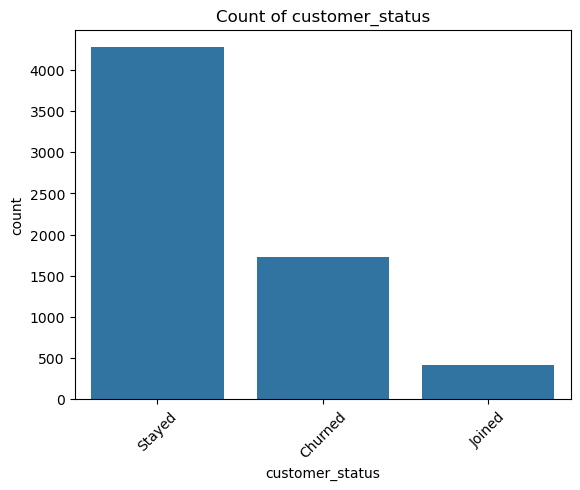

In [38]:
for col in ['gender','married','contract','internet_type','customer_status']:
    sns.countplot(x=col, data=df)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.show()


<Axes: >

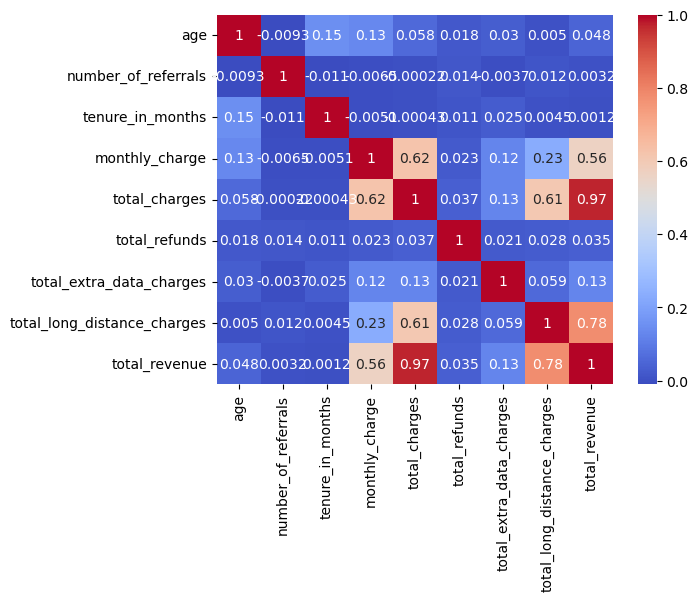

In [39]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')


In [45]:
#hypothesis 
# t-test
from scipy.stats import ttest_ind

stayed = df[df['customer_status']=='Stayed']['monthly_charge']
churned = df[df['customer_status']=='Churned']['monthly_charge']

t_stat, p_val = ttest_ind(stayed, churned)
print(f"T-stat: {t_stat}, p-value: {p_val}")


T-stat: -12.90057049282968, p-value: 1.405159714006558e-37


In [44]:
df['monthly_charge'].isna().sum().sum()

np.int64(0)

In [47]:
#chi-square

from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['internet_type'], df['customer_status'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi2: {chi2}, p-value: {p}")


Chi2: 637.554124807707, p-value: 1.8431034381859603e-134


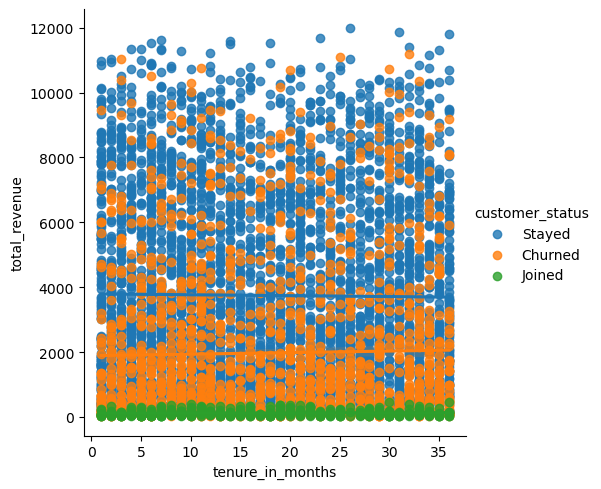

In [48]:
sns.lmplot(x='tenure_in_months', y='total_revenue', hue='customer_status', data=df)


In [49]:
from scipy.stats import f_oneway

month = df[df['contract']=='Month-to-Month']['total_revenue']
one_year = df[df['contract']=='One Year']['total_revenue']
two_year = df[df['contract']=='Two Year']['total_revenue']

f_stat, p_val = f_oneway(month, one_year, two_year)
print(f"F-stat: {f_stat}, p-value: {p_val}")


F-stat: 983.0974903095114, p-value: 0.0


In [51]:
df['Churn_Binary'] = df['customer_status'].replace({
    'Churned': 1,
    'Stayed': 0,
    'Joined': 0
})


C:\Users\Admin\AppData\Local\Temp\ipykernel_10844\1136475901.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn_Binary'] = df['customer_status'].replace({


In [54]:
df.columns

Index(['customer_id', 'gender', 'age', 'married', 'state',
       'number_of_referrals', 'tenure_in_months', 'value_deal',
       'phone_service', 'multiple_lines', 'internet_service', 'internet_type',
       'online_security', 'online_backup', 'device_protection_plan',
       'premium_support', 'streaming_tv', 'streaming_movies',
       'streaming_music', 'unlimited_data', 'contract', 'paperless_billing',
       'payment_method', 'monthly_charge', 'total_charges', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue', 'customer_status', 'churn_category', 'churn_reason',
       'Churn_Binary'],
      dtype='object')

In [55]:
# Select only numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Compute correlation with churn
corr_with_churn = df[num_cols].corr()['Churn_Binary'].sort_values(ascending=False)
print(corr_with_churn)


Churn_Binary                   1.000000
monthly_charge                 0.184209
age                            0.111899
total_extra_data_charges       0.015241
tenure_in_months               0.009934
number_of_referrals           -0.004637
total_refunds                 -0.035867
total_charges                 -0.200052
total_revenue                 -0.225664
total_long_distance_charges   -0.228623
Name: Churn_Binary, dtype: float64


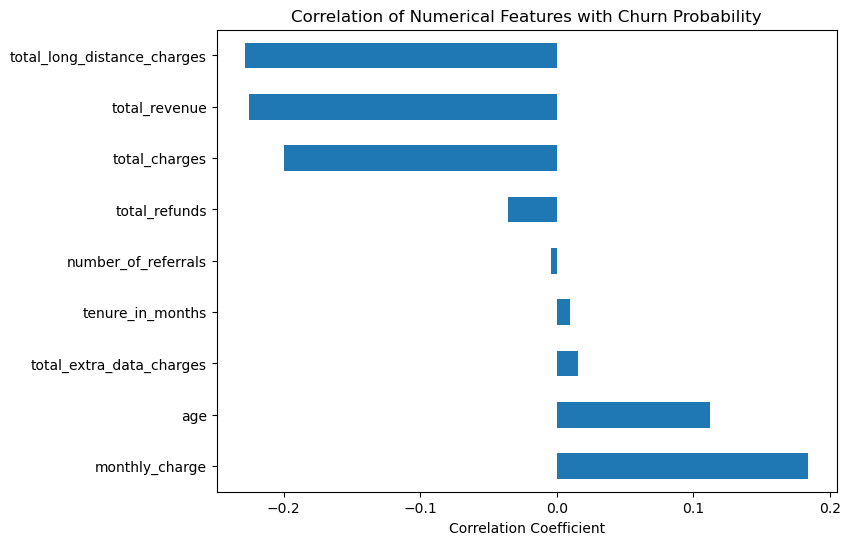

In [56]:
corr_with_churn.drop('Churn_Binary').plot(kind='barh', figsize=(8,6))
plt.title('Correlation of Numerical Features with Churn Probability')
plt.xlabel('Correlation Coefficient')
plt.show()


In [58]:
df_ml = df.drop(['customer_id', 'churn_category', 'churn_reason', 'customer_status'], axis=1)


In [59]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df_ml.select_dtypes(include='object').columns:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))


In [60]:
X = df_ml.drop('Churn_Binary', axis=1)
y = df_ml['Churn_Binary']


In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Accuracy: 0.8123052959501558
              precision    recall  f1-score   support

           0       0.86      0.89      0.88       965
           1       0.64      0.56      0.60       319

    accuracy                           0.81      1284
   macro avg       0.75      0.73      0.74      1284
weighted avg       0.81      0.81      0.81      1284



In [64]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.8325545171339563
              precision    recall  f1-score   support

           0       0.86      0.92      0.89       965
           1       0.71      0.55      0.62       319

    accuracy                           0.83      1284
   macro avg       0.79      0.74      0.76      1284
weighted avg       0.82      0.83      0.83      1284



In [65]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_gb))


Accuracy: 0.839563862928349


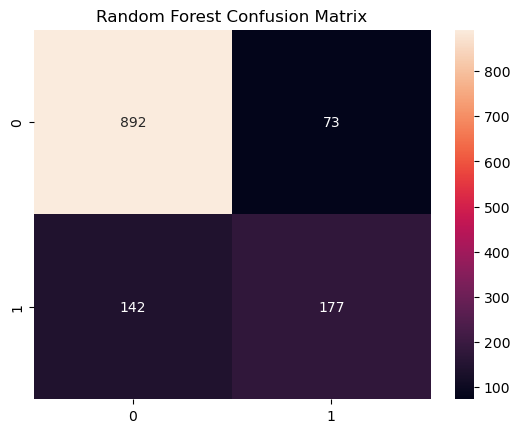

In [66]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()


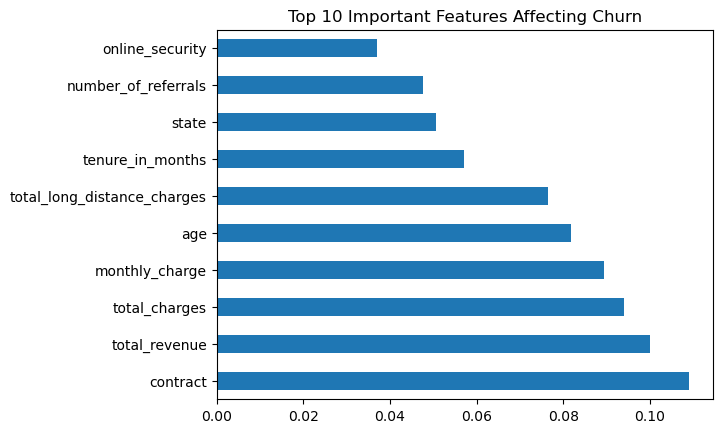

In [67]:

feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features Affecting Churn")
plt.show()
